# Fictalent · Auditoria de qualidade · cadastro, as regras do jogo
<a id="topo"></a>

[Home](../../README.md) | [Auditoria](README.md) | [Entendimento dos dados](../../docs/02_entendimento_dados.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 6, lake (v0.6.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 24/09/2026

**Objetivo:** auditar as tabelas de referência que todo o resto do banco aponta: geografia, filiais, funções, convenções e pisos, feriados, escalas, motivos e parâmetros. Defeito aqui se multiplica por todas as tabelas que referenciam.

**Base analisada:** a bronze do lake, lida pelo DuckDB com os nomes da réplica, só as linhas vivas (as marcadas como excluídas ficam de fora). Tabelas do domínio `cadastro`: `regiao`, `municipio`, `endereco`, `filial`, `motivo`, `funcao`, `convencao_coletiva`, `piso_salarial`, `feriado`, `escala`, `parametro`, `centro_custo`.

**Regra desta auditoria: às cegas.** O notebook procura os defeitos no dado com o esquema (a DDL) e o entendimento do negócio ([`docs/02`](../../docs/02_entendimento_dados.md)) como únicas referências. Ele não consulta o gerador da base sintética nem a régua de validação, e um teste garante isso. As declarações do cliente sobre a qualidade dos próprios dados entram como **hipóteses**, testadas aqui, não como resposta.

**Perguntas-guia:**

1. As chaves e os domínios que a DDL promete estão cumpridos na bronze, inclusive no tipo de cada coluna?
2. A geografia da Fictalent bate com a fonte pública (IBGE)? E os feriados, com a BrasilAPI?
3. As vigências (convenção, piso, parâmetro) são coerentes, sem buraco e sem sobreposição?
4. O texto de referência (nomes de município, logradouro, função) está limpo o bastante para servir de chave de junção?

**Sumário:**

1. [Configuração](#secao-1)
2. [A fotografia da carga](#secao-2)
3. [Perfil das colunas](#secao-3)
4. [Completude](#secao-4)
5. [Unicidade](#secao-5)
6. [Domínios declarados](#secao-6)
7. [Texto](#secao-7)
8. [Vigências e ordem temporal](#secao-8)
9. [Integridade referencial](#secao-9)
10. [Regras do domínio](#secao-10)
11. [Fechamento](#secao-11)

<a id="secao-1"></a>

# 1. Configuração

O acesso ao dado passa pelo pacote do projeto: endereço e credencial do lake vêm do `.env`, e o notebook não conhece nenhum dos dois. Assim ele roda na máquina de qualquer pessoa com a plataforma de pé, sem editar uma linha.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from rh_fictalent.auditoria import achados, checagens, esquema
from rh_fictalent.ingestao import marca_dagua
from rh_fictalent.lake import consulta
from rh_fictalent.orquestracao.recursos import lake_do_ambiente, warehouse_do_ambiente

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "auditoria" else Path.cwd()
load_dotenv(RAIZ / ".env")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print(f"Python {sys.version.split()[0]}")
for modulo in (pd, duckdb, matplotlib):
    print(f"{modulo.__name__:<12}{modulo.__version__}")

Python 3.12.3
pandas      3.0.5
duckdb      1.5.5
matplotlib  3.11.2


In [2]:
lake = lake_do_ambiente()
con = consulta.abrir(lake)
tabelas = esquema.do_modulo("cadastro")
nomes = [t.qualificado for t in tabelas]
registro = achados.Registro("cadastro")
print(f"{len(tabelas)} tabelas do domínio: {', '.join(t.nome for t in tabelas)}")

12 tabelas do domínio: regiao, municipio, endereco, filial, motivo, funcao, convencao_coletiva, piso_salarial, feriado, escala, parametro, centro_custo


## Nota Técnica

**Observado:** o ambiente carrega três dependências de análise (pandas, DuckDB, matplotlib) e o pacote do projeto; o lake é aberto por `consulta.abrir`, que cria uma view por tabela com os nomes da réplica. O domínio tem 12 tabelas, lidas da DDL.

**Por que importa:** o notebook não conhece endereço, chave nem senha: roda em qualquer máquina com o `.env` preenchido e pode ser publicado sem vazar credencial. Ler a lista de tabelas da DDL, em vez de digitá-la, faz tabela nova entrar na auditoria sozinha.

**Ação:** nenhuma: é a configuração esperada.

<a id="secao-2"></a>

# 2. A fotografia da carga

Toda conclusão descreve um instante. A marca d'água da ingestão diz até quando a bronze acompanha a réplica, e a contagem de linhas vivas diz o tamanho do que foi auditado. Os dois são lidos, não digitados, para não envelhecerem.

In [3]:
marcas = marca_dagua.ler(warehouse_do_ambiente())
do_dominio = {n: marcas[n] for n in nomes if n in marcas}
REFERENCIA = max(m.marca for m in do_dominio.values())
HOJE = REFERENCIA.date()
print(f"Marca d'água mais recente do domínio: {REFERENCIA:%d/%m/%Y %H:%M}")
print(f"Data de referência das regras com prazo (\"hoje\" do dado): {HOJE:%d/%m/%Y}")

volume = pd.DataFrame(
    [{"tabela": n, "linhas_vivas": checagens.linhas(con, n), "marca": do_dominio[n].marca if n in do_dominio else None} for n in nomes]
)
TOTAL = int(volume["linhas_vivas"].sum())
print(f"Linhas vivas no domínio: {TOTAL:,}".replace(",", "."))
volume

Marca d'água mais recente do domínio: 24/09/2026 15:02
Data de referência das regras com prazo ("hoje" do dado): 24/09/2026
Linhas vivas no domínio: 17.467


,tabela,linhas_vivas,marca
0,cadastro.regiao,5,2026-09-24 15:02:06.227515
1,cadastro.municipio,111,2026-09-24 15:02:06.227515
2,cadastro.endereco,15721,2026-09-24 15:02:06.227515
3,cadastro.filial,3,2026-09-24 15:02:06.227515
4,cadastro.motivo,45,2026-09-24 15:02:06.227515
5,cadastro.funcao,45,2026-09-24 15:02:06.227515
6,cadastro.convencao_coletiva,29,2026-09-24 15:02:06.227515
7,cadastro.piso_salarial,1305,2026-09-24 15:02:06.227515
8,cadastro.feriado,156,2026-09-24 15:02:06.227515
9,cadastro.escala,4,2026-09-24 15:02:06.227515


## Nota Técnica

**Observado:** a bronze das 12 tabelas acompanha a réplica até a marca d'água impressa acima (a carga incremental das 5h corre sozinha; a marca é o relógio da réplica). São 17.467 linhas vivas, das quais 15.721 são endereços; as demais tabelas têm de 3 a 1.305 linhas. Nenhuma linha marcada como excluída neste domínio.

**Por que importa:** todo número deste notebook descreve esta carga; a auditoria refeita depois de uma carga nova pode dar números diferentes, e isso não é contradição. Um domínio de referência pequeno e estável é a base que todas as junções do banco usam, e por isso vale uma auditoria inteira.

**Ação:** nenhuma. A data de referência (`HOJE`) alimenta as regras com prazo das seções 8 e 10.

<a id="secao-3"></a>

# 3. Perfil das colunas

Antes de procurar defeito é preciso saber o que há. Uma linha por coluna: tipo, nulos, distintos, mínimo e máximo. É o mapa que orienta as seções seguintes: coluna toda nula, coluna com um valor só, data fora do arco.

In [4]:
perfis = pd.concat([checagens.perfil(con, n) for n in nomes], ignore_index=True)
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0) & (perfis["tipo"] != "BOOLEAN")]
vazias = perfis[perfis["pct_nulo"] >= 100]
print(f"{len(perfis)} colunas em {len(nomes)} tabelas")
print(f"Colunas com um valor só: {len(constantes)}" + (f" ({', '.join(constantes['tabela'] + '.' + constantes['coluna'])})" if len(constantes) else ""))
print(f"Colunas totalmente vazias: {len(vazias)}" + (f" ({', '.join(vazias['tabela'] + '.' + vazias['coluna'])})" if len(vazias) else ""))
perfis

93 colunas em 12 tabelas
Colunas com um valor só: 10 (cadastro.regiao.criado_em, cadastro.regiao.atualizado_em, cadastro.municipio.criado_em, cadastro.municipio.atualizado_em, cadastro.motivo.criado_em, cadastro.motivo.atualizado_em, cadastro.funcao.criado_em, cadastro.funcao.atualizado_em, cadastro.escala.criado_em, cadastro.escala.atualizado_em)
Colunas totalmente vazias: 1 (cadastro.endereco.complemento)


,tabela,coluna,tipo,nulos,pct_nulo,distintos,minimo,maximo
0,cadastro.regiao,id,BIGINT,0,0.00,5,1,5
1,cadastro.regiao,nome,VARCHAR,0,0.00,5,Grande São Paulo,Sul de Minas · Fernão Dias
2,cadastro.regiao,criado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:00:00,2018-01-02 08:00:00
3,cadastro.regiao,atualizado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:00:00,2018-01-02 08:00:00
4,cadastro.municipio,id,BIGINT,0,0.00,115,1,111
5,cadastro.municipio,nome,VARCHAR,0,0.00,108,Albertina,Várzea Paulista
6,cadastro.municipio,uf,VARCHAR,0,0.00,2,MG,SP
7,cadastro.municipio,regiao_id,BIGINT,0,0.00,5,1,5
8,cadastro.municipio,codigo_ibge,VARCHAR,0,0.00,121,3101409,3556701
9,cadastro.municipio,criado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:00:00,2018-01-02 08:00:00


In [5]:
# a bronze promete ser espelho da réplica também no tipo: um inteiro copiado como booleano vira True em toda linha, e nenhuma contagem acusa
tipos = pd.concat([checagens.tipos(con, t) for t in tabelas], ignore_index=True)
incompativeis = tipos[~tipos["compativel"]]
print(f"{len(tipos)} colunas com o tipo conferido contra a DDL; incompatíveis: {len(incompativeis)}")
incompativeis

93 colunas com o tipo conferido contra a DDL; incompatíveis: 0


,tabela,coluna,ddl,bronze,compativel


In [6]:
registro.anotar(
    secao="3", tabela="cadastro.escala", coluna="dias_ciclo, mes_data_base (e, em outros domínios, etapa_funil.ordem e titulo_receber.numero_parcela)",
    achado="defeito de ingestão encontrado e corrigido: colunas TINYINT copiadas para a bronze como BOOLEAN (todo valor virava True)",
    linhas=0, total=TOTAL, severidade="nenhuma",
    impacto="a bronze não era espelho no tipo; o tamanho do ciclo da escala e o mês da data-base tinham virado True em toda linha, sem que nenhuma contagem acusasse",
    acao="feito nesta auditoria: o backfill passou a mapear como booleano só o tinyint(1) que a DDL usa para BOOLEAN, e as quatro tabelas foram recopiadas; a checagem de tipo entrou em toda auditoria",
)
print("anotado")

anotado


## Nota Técnica

**Observado:** 93 colunas. Dez são carimbos (`criado_em`, `atualizado_em`) com um valor só, todos em 02/01/2018 08:00: o cadastro inicial foi carregado de uma vez na implantação do sistema, e nunca foi editado. `endereco.complemento` é totalmente vazia (15.721 linhas). Os tipos da bronze foram conferidos contra a DDL coluna a coluna: **na primeira execução desta auditoria, esta checagem acusou `escala.dias_ciclo` e `convencao_coletiva.mes_data_base` copiados como `BOOLEAN`** (todo valor virou `True`), junto com `ats.etapa_funil.ordem` e `financeiro.titulo_receber.numero_parcela` em outros domínios. A causa era a ingestão tratar todo `tinyint` do MySQL como booleano, sem olhar se era o `tinyint(1)` que a DDL usa para `BOOLEAN`. O backfill foi corrigido, as quatro tabelas recopiadas, e a execução versionada já mostra zero incompatibilidades.

**Por que importa:** a bronze promete ser espelho da réplica, e a régua só conferia a contagem de linhas: um inteiro copiado como booleano passa por todas as contagens e estraga qualquer regra que use o valor (o tamanho do ciclo da escala é o que diz quantos dias uma pessoa trabalha e folga). A checagem de tipo passa a fazer parte de toda auditoria deste projeto por causa disso.

**Ação:** a correção da ingestão já foi feita e testada (`tests/test_backfill.py`). Fica anotado como achado de severidade `nenhuma`, para o catálogo registrar que a bronze foi recopiada e por quê.

<a id="secao-4"></a>

# 4. Completude

Campo vazio não é necessariamente defeito. Há o vazio legítimo (o fato ainda não aconteceu: vigência sem fim é vigência aberta), o vazio por regra (o campo não se aplica: feriado nacional não tem município) e o vazio por falha, que é o único que vira achado. As colunas que a DDL declara `NOT NULL` não podem ter nulo; se tiverem, a bronze não é espelho.

In [7]:
obrigatorias = {(t.qualificado, c.nome) for t in tabelas for c in t.colunas if not c.nulo}
com_nulos = perfis[perfis["nulos"] > 0].sort_values("pct_nulo", ascending=False)
com_nulos = com_nulos.assign(obrigatoria=[(t, c) in obrigatorias for t, c in zip(com_nulos["tabela"], com_nulos["coluna"])])
violacao = com_nulos[com_nulos["obrigatoria"]]
print(f"Colunas com algum nulo: {len(com_nulos)}; delas, declaradas NOT NULL: {len(violacao)}")
com_nulos[["tabela", "coluna", "tipo", "nulos", "pct_nulo", "obrigatoria"]]

Colunas com algum nulo: 7; delas, declaradas NOT NULL: 0


,tabela,coluna,tipo,nulos,pct_nulo,obrigatoria
14,cadastro.endereco,complemento,VARCHAR,15721,100.00,False
68,cadastro.feriado,municipio_id,BIGINT,129,82.69,False
82,cadastro.parametro,vigencia_fim,DATE,8,80.00,False
40,cadastro.funcao,cbo,VARCHAR,17,37.78,False
90,cadastro.centro_custo,contrato_id,BIGINT,4,12.12,False
52,cadastro.convencao_coletiva,vigencia_fim,DATE,3,10.34,False
61,cadastro.piso_salarial,vigencia_fim,DATE,135,10.34,False


In [8]:
# o nulo é coerente com a regra que o explica?
coerencia = consulta.sql(con, '''
    SELECT 'feriado: municipio_id nulo fora de NACIONAL/ESTADUAL' AS caso, count(*) AS linhas FROM cadastro.feriado WHERE excluido_em IS NULL AND municipio_id IS NULL AND abrangencia = 'MUNICIPAL'
    UNION ALL SELECT 'feriado: MUNICIPAL sem municipio', count(*) FROM cadastro.feriado WHERE excluido_em IS NULL AND abrangencia = 'MUNICIPAL' AND municipio_id IS NULL
    UNION ALL SELECT 'centro_custo: CONTRATO sem contrato_id', count(*) FROM cadastro.centro_custo WHERE excluido_em IS NULL AND tipo = 'CONTRATO' AND contrato_id IS NULL
    UNION ALL SELECT 'centro_custo: FILIAL/RETAGUARDA com contrato_id', count(*) FROM cadastro.centro_custo WHERE excluido_em IS NULL AND tipo <> 'CONTRATO' AND contrato_id IS NOT NULL
''')
print(coerencia.to_string(index=False))
sem_cbo = consulta.sql(con, "SELECT familia, nivel, count(*) AS funcoes, count(cbo) AS com_cbo FROM cadastro.funcao WHERE excluido_em IS NULL GROUP BY 1, 2 ORDER BY 1, 2")
print()
print(sem_cbo.to_string(index=False))

                                                caso  linhas
feriado: municipio_id nulo fora de NACIONAL/ESTADUAL       0
                    feriado: MUNICIPAL sem municipio       0
              centro_custo: CONTRATO sem contrato_id       0
     centro_custo: FILIAL/RETAGUARDA com contrato_id       0

       familia    nivel  funcoes  com_cbo
ADMINISTRATIVO AUXILIAR        3        3
ADMINISTRATIVO OPERADOR        3        2
ADMINISTRATIVO  TECNICO        1        0
      COMERCIO AUXILIAR        3        1
      COMERCIO OPERADOR        6        4
     LOGISTICA AUXILIAR        5        2
     LOGISTICA    LIDER        1        0
     LOGISTICA OPERADOR        5        4
     LOGISTICA  TECNICO        1        0
      PRODUCAO AUXILIAR        3        2
      PRODUCAO    LIDER        1        0
      PRODUCAO OPERADOR        5        2
      PRODUCAO  TECNICO        3        3
      SERVICOS AUXILIAR        5        5


In [9]:
n_funcoes = checagens.linhas(con, "cadastro.funcao")
n_sem_cbo = checagens.contar(con, "SELECT count(*) FROM cadastro.funcao WHERE excluido_em IS NULL AND cbo IS NULL")
registro.anotar(
    secao="4", tabela="cadastro.funcao", coluna="cbo",
    achado="função sem código CBO", linhas=n_sem_cbo, total=n_funcoes, severidade="media",
    impacto="o CBO é o código de ocupação do eSocial e o que liga a função às estatísticas públicas de emprego; sem ele, 17 funções (líderes e analistas entre elas) ficam fora de qualquer cruzamento por ocupação",
    acao="pedir os códigos ao cliente; na silver a ausência não se preenche (inventar CBO cria dado que ninguém coletou)",
)
n_enderecos = checagens.linhas(con, "cadastro.endereco")
registro.anotar(
    secao="4", tabela="cadastro.endereco", coluna="complemento",
    achado="coluna nunca preenchida", linhas=int(perfis.loc[(perfis["tabela"] == "cadastro.endereco") & (perfis["coluna"] == "complemento"), "nulos"].iloc[0]), total=n_enderecos, severidade="baixa",
    impacto="a coluna existe e não informa nada; relatório que a use mostra vazio e parece defeito",
    acao="documentar como não coletada e deixá-la fora do modelo dimensional até que passe a ser preenchida",
)
print(f"anotados: {len(registro)} achados")

anotados: 3 achados


## Nota Técnica

**Observado:** sete colunas têm nulo e nenhuma delas é `NOT NULL` na DDL: a bronze respeita a obrigatoriedade. Os nulos são coerentes com a regra que os explica: `feriado.municipio_id` só é nulo nos 129 feriados nacionais e estaduais (os 27 municipais têm município); `centro_custo.contrato_id` só é nulo nos 4 centros de filial e retaguarda (os 29 de contrato têm contrato); os `vigencia_fim` nulos são as vigências abertas (3 convenções, 135 pisos, 8 parâmetros). Sobram dois casos: `funcao.cbo` vazio em 17 das 45 funções (37,8%), espalhadas por todas as famílias, e `endereco.complemento` nunca preenchido.

**Por que importa:** vazio legítimo e vazio por regra não se tratam; vazio por falha, sim, e o CBO é falha: é o código de ocupação que o eSocial exige e que liga a função da Fictalent às estatísticas públicas de emprego por ocupação. Sem ele, 17 funções (incluindo líderes e analistas) ficam fora de qualquer cruzamento por ocupação. O complemento nunca preenchido não é defeito de linha: é uma coluna que o sistema oferece e ninguém usa.

**Ação:** anotar `funcao.cbo` como achado de severidade média (pedir os 17 códigos ao cliente; na silver a ausência não se preenche, porque inventar CBO cria dado que ninguém coletou) e `endereco.complemento` como baixa (documentar como não coletada; candidata a ficar fora do modelo dimensional).

<a id="secao-5"></a>

# 5. Unicidade

Duas perguntas diferentes. A chave declarada (`UNIQUE` na DDL) está íntegra? E a duplicidade de conteúdo, a que passa por qualquer chave porque, para o banco, `Atibaia` e `ATIBAIA ` são textos diferentes?

In [10]:
linhas_unicas = []
for t in tabelas:
    for chave in t.unicas:
        grupos, envolvidas = checagens.repetidos(con, t.qualificado, list(chave))
        linhas_unicas.append({"tabela": t.qualificado, "chave": ", ".join(chave), "grupos_repetidos": grupos, "linhas": envolvidas})
unicas = pd.DataFrame(linhas_unicas)
print(f"{len(unicas)} chaves UNIQUE conferidas; com repetição: {int((unicas['grupos_repetidos'] > 0).sum())}")
unicas

8 chaves UNIQUE conferidas; com repetição: 0


,tabela,chave,grupos_repetidos,linhas
0,cadastro.regiao,nome,0,0
1,cadastro.municipio,codigo_ibge,0,0
2,cadastro.filial,codigo,0,0
3,cadastro.motivo,"tipo, codigo",0,0
4,cadastro.funcao,codigo,0,0
5,cadastro.escala,codigo,0,0
6,cadastro.parametro,"chave, vigencia_inicio",0,0
7,cadastro.centro_custo,codigo,0,0


In [11]:
conteudo = {
    ("cadastro.municipio", ("nome", "uf")): "o mesmo município cadastrado duas vezes",
    ("cadastro.endereco", ("logradouro", "numero", "complemento", "bairro", "municipio_id")): "o mesmo endereço cadastrado mais de uma vez",
    ("cadastro.funcao", ("nome",)): "a mesma função com dois códigos",
    ("cadastro.motivo", ("tipo", "descricao")): "o mesmo motivo com dois códigos",
    ("cadastro.feriado", ("data", "abrangencia", "municipio_id")): "o mesmo feriado lançado duas vezes",
}
repetidos_conteudo = 0
for (tabela, colunas), descricao in conteudo.items():
    grupos, envolvidas = checagens.repetidos(con, tabela, list(colunas), normalizar=True)
    repetidos_conteudo += envolvidas
    print(f"{tabela:<22} {'+'.join(colunas):<48} {grupos:>4} grupos  {envolvidas:>5} linhas   ({descricao})")
registro.anotar(
    secao="5", tabela="cadastro.endereco", coluna="logradouro, numero, complemento, bairro, municipio_id",
    achado="hipótese refutada: não há endereço nem outro cadastro de referência duplicado por conteúdo", linhas=repetidos_conteudo, total=n_enderecos, severidade="nenhuma",
    impacto="não há conformação de cadastro a fazer neste domínio", acao="nenhuma",
)

cadastro.municipio     nome+uf                                             0 grupos      0 linhas   (o mesmo município cadastrado duas vezes)
cadastro.endereco      logradouro+numero+complemento+bairro+municipio_id    0 grupos      0 linhas   (o mesmo endereço cadastrado mais de uma vez)
cadastro.funcao        nome                                                0 grupos      0 linhas   (a mesma função com dois códigos)
cadastro.motivo        tipo+descricao                                      0 grupos      0 linhas   (o mesmo motivo com dois códigos)
cadastro.feriado       data+abrangencia+municipio_id                       0 grupos      0 linhas   (o mesmo feriado lançado duas vezes)


Achado(dominio='cadastro', secao='5', tabela='cadastro.endereco', coluna='logradouro, numero, complemento, bairro, municipio_id', achado='hipótese refutada: não há endereço nem outro cadastro de referência duplicado por conteúdo', linhas=0, total=15721, severidade='nenhuma', impacto='não há conformação de cadastro a fazer neste domínio', acao='nenhuma', declaracao='')

## Nota Técnica

**Observado:** as 8 chaves `UNIQUE` da DDL estão íntegras, e a duplicidade de conteúdo, procurada com texto normalizado (sem acento, caixa ou espaço sobrando), não existe: nenhum município, endereço, função, motivo ou feriado cadastrado duas vezes.

**Por que importa:** chave única intacta significa que as junções por código (função, escala, centro de custo, município) são confiáveis. Endereço sem duplicata de conteúdo é raro em base real e merece ser dito: 15.721 endereços de colaborador sem um repetido por grafia.

**Ação:** nenhuma. Registrar a hipótese refutada no fechamento, para o catálogo saber que não há conformação de cadastro a fazer neste domínio.

<a id="secao-6"></a>

# 6. Domínios declarados

Toda coluna com `CHECK (... IN (...))` na DDL tem um domínio fechado. O banco de origem barra valor fora dele; a bronze, copiada por lote, precisa mostrar o mesmo. Valor fora do domínio aqui é defeito da cópia, não do sistema.

In [12]:
dominios = pd.concat([checagens.dominios(con, t) for t in tabelas], ignore_index=True)
print(f"{len(dominios)} domínios conferidos; com valor fora: {int((dominios['fora'] > 0).sum())}")
dominios

5 domínios conferidos; com valor fora: 0


,tabela,coluna,esperados,fora,exemplos
0,cadastro.endereco,tipo,4,0,
1,cadastro.filial,tipo,2,0,
2,cadastro.motivo,tipo,7,0,
3,cadastro.feriado,abrangencia,3,0,
4,cadastro.centro_custo,tipo,3,0,


## Nota Técnica

**Observado:** os 5 domínios declarados em `CHECK` (tipo de endereço, tipo de filial, tipo de motivo, abrangência de feriado, tipo de centro de custo) só contêm os valores previstos.

**Por que importa:** domínio limpo é consequência de o sistema de origem usar restrição de domínio no banco em vez de texto livre, e a bronze mostra que a cópia por lote preservou isso. As colunas podem ser usadas direto como dimensão, sem etapa de padronização.

**Ação:** nenhuma.

<a id="secao-7"></a>

# 7. Texto

O texto digitado por pessoas é o ponto frágil de qualquer base. Aqui ele importa mais do que de costume porque as colunas de referência viram chave de junção e rótulo de painel: uma cidade em duas grafias é uma cidade contada duas vezes.

In [13]:
campos = [("cadastro.municipio", "nome"), ("cadastro.endereco", "logradouro"), ("cadastro.endereco", "bairro"), ("cadastro.funcao", "nome"), ("cadastro.motivo", "descricao"), ("cadastro.convencao_coletiva", "sindicato")]
vicios = pd.DataFrame([{"campo": f"{t}.{c}", **checagens.texto_inconsistente(con, t, c)} for t, c in campos]).set_index("campo")
print(f"Vícios de texto somados nos {len(campos)} campos: {int(vicios.to_numpy().sum())}")
vicios

Vícios de texto somados nos 6 campos: 0


,espacos_nas_pontas,espacos_duplos,caixa_alta,caixa_baixa,valores_com_mais_de_uma_grafia,linhas_em_grafia_multipla
campo,,,,,,
cadastro.municipio.nome,0,0,0,0,0,0
cadastro.endereco.logradouro,0,0,0,0,0,0
cadastro.endereco.bairro,0,0,0,0,0,0
cadastro.funcao.nome,0,0,0,0,0,0
cadastro.motivo.descricao,0,0,0,0,0,0
cadastro.convencao_coletiva.sindicato,0,0,0,0,0,0


## Nota Técnica

**Observado:** seis campos de texto (nome de município, logradouro, bairro, nome de função, descrição de motivo, sindicato) sem nenhum vício: zero espaços nas pontas, zero espaço duplo, zero caixa alta ou baixa integral, zero valor em mais de uma grafia.

**Por que importa:** é o oposto do que se encontra em base real, onde o texto digitado é o ponto mais frágil. Aqui o cadastro de referência parece ter entrado por carga estruturada (os carimbos de 02/01/2018 sugerem isso), não por digitação. Vale registrar como ponto forte, e vale desconfiar do mesmo resultado nos domínios com digitação diária (candidatos, contatos), auditados nos notebooks seguintes.

**Ação:** nenhuma.

<a id="secao-8"></a>

# 8. Vigências e ordem temporal

Convenção, piso e parâmetro têm vigência. Três defeitos possíveis: fim antes do início, dois períodos do mesmo objeto se cruzando (qual piso vale em março?) e o buraco, um objeto sem valor vigente numa data em que ele era necessário. O buraco é conferido na data de referência da carga.

In [14]:
periodos = [
    ("cadastro.convencao_coletiva", "vigencia_inicio", "vigencia_fim", ["municipio_id", "sindicato"]),
    ("cadastro.piso_salarial", "vigencia_inicio", "vigencia_fim", ["convencao_id", "funcao_id"]),
    ("cadastro.parametro", "vigencia_inicio", "vigencia_fim", ["chave"]),
]
for tabela, inicio, fim, grupo in periodos:
    invertidos = checagens.ordem_temporal(con, tabela, inicio, fim)
    cruzados = checagens.sobreposicoes(con, tabela, grupo, inicio, fim)
    print(f"{tabela:<30} fim antes do início: {invertidos:>3}   períodos cruzados no mesmo {'+'.join(grupo)}: {cruzados:>3}")

cadastro.convencao_coletiva    fim antes do início:   0   períodos cruzados no mesmo municipio_id+sindicato:   0


cadastro.piso_salarial         fim antes do início:   0   períodos cruzados no mesmo convencao_id+funcao_id:   0
cadastro.parametro             fim antes do início:   0   períodos cruzados no mesmo chave:   0


In [15]:
# o buraco: função com convenção vigente hoje mas sem piso vigente hoje
buracos = consulta.sql(con, '''
    SELECT c.id AS convencao_id, c.sindicato, f.codigo AS funcao, f.nome
    FROM cadastro.convencao_coletiva c
    CROSS JOIN cadastro.funcao f
    WHERE c.excluido_em IS NULL AND f.excluido_em IS NULL
      AND c.vigencia_inicio <= ? AND coalesce(c.vigencia_fim, DATE '9999-12-31') >= ?
      AND NOT EXISTS (
        SELECT 1 FROM cadastro.piso_salarial p
        WHERE p.excluido_em IS NULL AND p.convencao_id = c.id AND p.funcao_id = f.id
          AND p.vigencia_inicio <= ? AND coalesce(p.vigencia_fim, DATE '9999-12-31') >= ?)
''', HOJE, HOJE, HOJE, HOJE)
print(f"Pares convenção × função sem piso vigente em {HOJE:%d/%m/%Y}: {len(buracos)}")
buracos.head(10)

Pares convenção × função sem piso vigente em 24/09/2026: 0


,convencao_id,sindicato,funcao,nome


In [16]:
# piso: valor por ano de vigência, para ver se a escala é plausível e se cresce
piso_ano = consulta.sql(con, '''
    SELECT year(vigencia_inicio) AS ano, count(*) AS pisos, min(valor_piso) AS minimo, median(valor_piso) AS mediana, max(valor_piso) AS maximo,
           min(adicional_insalubridade_pct) AS insal_min, max(adicional_insalubridade_pct) AS insal_max
    FROM cadastro.piso_salarial WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 1''')
print(f"Pisos com valor <= 0: {checagens.fora_da_faixa(con, 'cadastro.piso_salarial', 'valor_piso', minimo=0.01)}")
piso_ano

Pisos com valor <= 0: 0


,ano,pisos,minimo,mediana,maximo,insal_min,insal_max
0,2017,90,"1,137.10","1,364.45","2,628.45",0.00,0.20
1,2018,135,"1,118.54","1,351.59","2,683.65",0.00,0.20
2,2019,135,"1,162.16","1,404.30","2,788.31",0.00,0.20
3,2020,135,"1,200.51","1,450.64","2,880.32",0.00,0.20
4,2021,135,"1,274.95","1,540.58","3,058.90",0.00,0.20
5,2022,135,"1,412.64","1,706.97","3,389.27",0.00,0.20
6,2023,135,"1,490.34","1,800.85","3,575.67",0.00,0.20
7,2024,135,"1,548.46","1,871.08","3,715.13",0.00,0.20
8,2025,135,"1,624.33","1,962.76","3,897.17",0.00,0.20
9,2026,135,"1,695.80","2,049.13","4,068.64",0.00,0.20


## Nota Técnica

**Observado:** nenhuma vigência com fim antes do início, nenhum período cruzado (convenção por município e sindicato, piso por convenção e função, parâmetro por chave) e nenhum buraco: toda convenção vigente em `HOJE` tem piso vigente para as 45 funções. Os 1.305 pisos cobrem 2017 a 2026 (a convenção de 2017 é a que valia na abertura do arco), com mediana subindo de R$ 1.364 para R$ 2.049 e adicional de insalubridade entre 0 e 20%. Nenhum piso menor ou igual a zero.

**Por que importa:** o piso é o que a folha usa para calcular salário e o que o comercial usa para precificar um posto; um piso ausente numa data faria a folha do mês pegar o valor errado em silêncio. A escala dos valores é plausível para as funções do caso e cresce ano a ano, como uma convenção coletiva faz.

**Ação:** nenhuma.

<a id="secao-9"></a>

# 9. Integridade referencial

Toda chave estrangeira da DDL, conferida na bronze: a linha filha aponta para uma mãe viva? Uma mãe marcada como excluída conta como ausente, porque é exatamente o caso que a bronze existe para mostrar. Há também uma referência que a DDL **não** declara como chave: `centro_custo.contrato_id`, que aponta para outro módulo; ela é conferida à mão.

In [17]:
integridade = pd.concat([checagens.integridade(con, t) for t in tabelas], ignore_index=True)
print(f"{len(integridade)} chaves estrangeiras conferidas; com órfãos: {int((integridade['orfaos'] > 0).sum())}")
sem_fk = checagens.orfaos(con, "cadastro.centro_custo", "contrato_id", "comercial.contrato")
print(f"centro_custo.contrato_id sem contrato correspondente (referência sem FK na DDL): {sem_fk}")
integridade

8 chaves estrangeiras conferidas; com órfãos: 0
centro_custo.contrato_id sem contrato correspondente (referência sem FK na DDL): 0


,tabela,coluna,alvo,orfaos
0,cadastro.municipio,regiao_id,cadastro.regiao,0
1,cadastro.endereco,municipio_id,cadastro.municipio,0
2,cadastro.filial,endereco_id,cadastro.endereco,0
3,cadastro.convencao_coletiva,municipio_id,cadastro.municipio,0
4,cadastro.piso_salarial,convencao_id,cadastro.convencao_coletiva,0
5,cadastro.piso_salarial,funcao_id,cadastro.funcao,0
6,cadastro.feriado,municipio_id,cadastro.municipio,0
7,cadastro.centro_custo,filial_id,cadastro.filial,0


## Nota Técnica

**Observado:** as 8 chaves estrangeiras da DDL sem órfão, e a referência que a DDL não declara como chave, `centro_custo.contrato_id` para `comercial.contrato`, também sem órfão (29 de 29).

**Por que importa:** integridade intacta permite fazer junções sem perder linha pelo caminho, o que nem todo sistema garante. A referência sem FK declarada é a que mais merece a conferência, porque nada no banco a protege; ela passou.

**Ação:** nenhuma. Sugerir ao cliente declarar a chave estrangeira de `centro_custo.contrato_id` na DDL, já que o dado a respeita.

<a id="secao-10"></a>

# 10. Regras do domínio

O que o esquema não declara mas o negócio exige, conferido contra as fontes públicas que o próprio pipeline ingere: os municípios contra a tabela do IBGE, os feriados nacionais contra a BrasilAPI, o CEP no formato, a UF válida, a escala dentro da lei.

In [18]:
# municípios: o código IBGE existe na fonte? o nome e a UF batem?
ibge = consulta.sql(con, '''
    SELECT m.id, m.codigo_ibge, m.nome, m.uf, i.nome AS nome_ibge, i.uf AS uf_ibge
    FROM cadastro.municipio m
    LEFT JOIN fontes.municipios i ON CAST(i.codigo_ibge AS VARCHAR) = m.codigo_ibge
    WHERE m.excluido_em IS NULL''')
sem_fonte = ibge[ibge["nome_ibge"].isna()]
nome_diverge = ibge[ibge["nome_ibge"].notna() & (ibge["nome"].str.strip().str.lower() != ibge["nome_ibge"].str.strip().str.lower())]
uf_diverge = ibge[ibge["uf_ibge"].notna() & (ibge["uf"] != ibge["uf_ibge"])]
print(f"Municípios: {len(ibge)}; código IBGE sem correspondência na fonte: {len(sem_fonte)}; nome divergente: {len(nome_diverge)}; UF divergente: {len(uf_diverge)}")
print(f"UFs presentes: {sorted(ibge['uf'].unique())}")

Municípios: 111; código IBGE sem correspondência na fonte: 0; nome divergente: 0; UF divergente: 0
UFs presentes: ['MG', 'SP']


In [19]:
# feriados nacionais: o que a BrasilAPI diz que existe e a bronze não tem, e vice-versa (a fonte só cobre os anos materializados no lake)
feriados = consulta.sql(con, '''
    WITH fonte AS (SELECT CAST(data AS DATE) AS data, nome FROM fontes.feriados),
         bronze AS (SELECT data, nome FROM cadastro.feriado WHERE excluido_em IS NULL AND abrangencia = 'NACIONAL')
    SELECT year(coalesce(f.data, b.data)) AS ano,
           count(f.data) AS na_fonte, count(b.data) AS na_bronze,
           count(*) FILTER (WHERE b.data IS NULL) AS faltam_na_bronze,
           count(*) FILTER (WHERE f.data IS NULL AND year(b.data) IN (SELECT DISTINCT ano FROM fontes.feriados)) AS sobram_na_bronze
    FROM fonte f FULL OUTER JOIN bronze b ON f.data = b.data
    GROUP BY 1 ORDER BY 1''')
anos_da_fonte = sorted(int(a) for a in consulta.sql(con, "SELECT DISTINCT ano FROM fontes.feriados")["ano"])
print(f"Anos materializados da fonte de feriados: {anos_da_fonte}")
feriados

Anos materializados da fonte de feriados: [2024]


,ano,na_fonte,na_bronze,faltam_na_bronze,sobram_na_bronze
0,2018,0,13,0,0
1,2019,0,13,0,0
2,2020,0,13,0,0
3,2021,0,13,0,0
4,2022,0,13,0,0
5,2023,0,13,0,0
6,2024,14,14,0,0
7,2025,0,14,0,0
8,2026,0,14,0,0


In [20]:
cep_ruim = checagens.contar(con, "SELECT count(*) FROM cadastro.endereco WHERE excluido_em IS NULL AND cep IS NOT NULL AND NOT regexp_matches(cep, '^[0-9]{8}$')")
uf_ruim = checagens.contar(con, "SELECT count(*) FROM cadastro.municipio WHERE excluido_em IS NULL AND NOT regexp_matches(uf, '^[A-Z]{2}$')")
escala_ruim = checagens.fora_da_faixa(con, "cadastro.escala", "horas_semanais", minimo=1, maximo=44)
ciclo_ruim = checagens.fora_da_faixa(con, "cadastro.escala", "dias_ciclo", minimo=1)
feriado_fora = checagens.contar(con, "SELECT count(*) FROM cadastro.feriado WHERE excluido_em IS NULL AND (data < DATE '2018-01-01' OR data > DATE '2027-12-31')")
print(f"CEP fora do formato de 8 dígitos: {cep_ruim}")
print(f"UF fora do formato: {uf_ruim}")
print(f"Escala com horas semanais fora de 1..44: {escala_ruim}; dias de ciclo < 1: {ciclo_ruim}")
print(f"Feriado fora do arco 2018..2027: {feriado_fora}")
print(consulta.sql(con, "SELECT codigo, descricao, horas_semanais, dias_ciclo FROM cadastro.escala WHERE excluido_em IS NULL ORDER BY codigo").to_string(index=False))

CEP fora do formato de 8 dígitos: 0
UF fora do formato: 0
Escala com horas semanais fora de 1..44: 0; dias de ciclo < 1: 0
Feriado fora do arco 2018..2027: 0
codigo                                               descricao  horas_semanais  dias_ciclo
 12X36    Doze horas de trabalho por trinta e seis de descanso           42.00           2
   5X1     Cinco dias de trabalho, um de folga, em revezamento           42.00           6
   5X2 Cinco dias de trabalho, dois de folga (segunda a sexta)           44.00           7
   6X1                      Seis dias de trabalho, um de folga           44.00           7


In [21]:
conferidos = int(feriados.loc[feriados["ano"].isin(anos_da_fonte), "na_fonte"].sum())
faltam = int(feriados["faltam_na_bronze"].sum())
registro.anotar(
    secao="10", tabela="cadastro.feriado", coluna="data",
    achado=f"feriados nacionais conferidos contra a BrasilAPI só nos anos que a fonte tem no lake ({', '.join(str(a) for a in anos_da_fonte)}): {conferidos - faltam} de {conferidos}; os demais anos aguardam a carga da fonte",
    linhas=faltam, total=checagens.linhas(con, "cadastro.feriado"), severidade="nenhuma",
    impacto="feriado errado distorce todo indicador em dias úteis (tempo para preencher vaga, dias descobertos, apontamento); a conferência parcial não acusou nada",
    acao="materializar fontes/brasilapi/feriados para 2018 a 2026 e repetir a conferência antes do catálogo (pendência do pipeline, não do dado)",
)
print(f"anotados: {len(registro)} achados")

anotados: 5 achados


## Nota Técnica

**Observado:** os 111 municípios existem na tabela do IBGE que o próprio pipeline ingere, com nome e UF idênticos (só MG e SP, que é o escopo do caso). Os feriados nacionais foram conferidos contra a BrasilAPI no único ano que a fonte tem carregado, 2024: 14 de 14, sem falta e sem sobra; a bronze tem 13 nacionais por ano até 2023 e 14 a partir de 2024, o que é coerente com o Dia da Consciência Negra virar feriado nacional em 2024. CEP, UF, escala (42 e 44 horas semanais) e arco dos feriados, tudo dentro do formato.

**Por que importa:** a geografia é a dimensão mais reutilizada do BI, e bater com o IBGE código a código é o que permite enriquecer com qualquer dado público (CAGED, censo) sem tabela de-para. A conferência dos feriados só vale para 2024 porque a fonte pública só tem esse ano materializado no lake: é uma pendência do pipeline, não do dado.

**Ação:** materializar `fontes/brasilapi/feriados` para 2018 a 2026 antes do catálogo, e repetir a conferência. Anotado como achado de severidade `nenhuma`, com a ação.

<a id="secao-11"></a>

# 11. Fechamento

Os achados das seções anteriores, consolidados por severidade, e o registro gravado em `dados/auditoria/` para o catálogo de achados, que é onde as regras de tratamento serão propostas e aprovadas antes de qualquer transformação.

In [22]:
print(registro.resumo().to_string(index=False))
print(f"\nTotal: {len(registro)} achados")
quadro = registro.tabela()
quadro[["severidade", "secao", "tabela", "coluna", "achado", "linhas", "total", "pct", "declaracao"]]

severidade  achados
      alta        0
     media        1
     baixa        1
   nenhuma        3

Total: 5 achados


,severidade,secao,tabela,coluna,achado,linhas,total,pct,declaracao
0,media,4,cadastro.funcao,cbo,função sem código CBO,17,45,37.78,
1,baixa,4,cadastro.endereco,complemento,coluna nunca preenchida,15721,15721,100.00,
2,nenhuma,3,cadastro.escala,"dias_ciclo, mes_data_base (e, em outros domínios, etapa_funil.ordem e titulo_receber.numero_parc...",defeito de ingestão encontrado e corrigido: colunas TINYINT copiadas para a bronze como BOOLEAN ...,0,17467,0.00,
3,nenhuma,5,cadastro.endereco,"logradouro, numero, complemento, bairro, municipio_id",hipótese refutada: não há endereço nem outro cadastro de referência duplicado por conteúdo,0,15721,0.00,
4,nenhuma,10,cadastro.feriado,data,feriados nacionais conferidos contra a BrasilAPI só nos anos que a fonte tem no lake (2024): 14 ...,0,156,0.00,


In [23]:
quadro[["severidade", "tabela", "coluna", "impacto", "acao"]]

,severidade,tabela,coluna,impacto,acao
0,media,cadastro.funcao,cbo,o CBO é o código de ocupação do eSocial e o que liga a função às estatísticas públicas de empreg...,pedir os códigos ao cliente; na silver a ausência não se preenche (inventar CBO cria dado que ni...
1,baixa,cadastro.endereco,complemento,a coluna existe e não informa nada; relatório que a use mostra vazio e parece defeito,documentar como não coletada e deixá-la fora do modelo dimensional até que passe a ser preenchida
2,nenhuma,cadastro.escala,"dias_ciclo, mes_data_base (e, em outros domínios, etapa_funil.ordem e titulo_receber.numero_parc...",a bronze não era espelho no tipo; o tamanho do ciclo da escala e o mês da data-base tinham virad...,feito nesta auditoria: o backfill passou a mapear como booleano só o tinyint(1) que a DDL usa pa...
3,nenhuma,cadastro.endereco,"logradouro, numero, complemento, bairro, municipio_id",não há conformação de cadastro a fazer neste domínio,nenhuma
4,nenhuma,cadastro.feriado,data,"feriado errado distorce todo indicador em dias úteis (tempo para preencher vaga, dias descoberto...",materializar fontes/brasilapi/feriados para 2018 a 2026 e repetir a conferência antes do catálog...


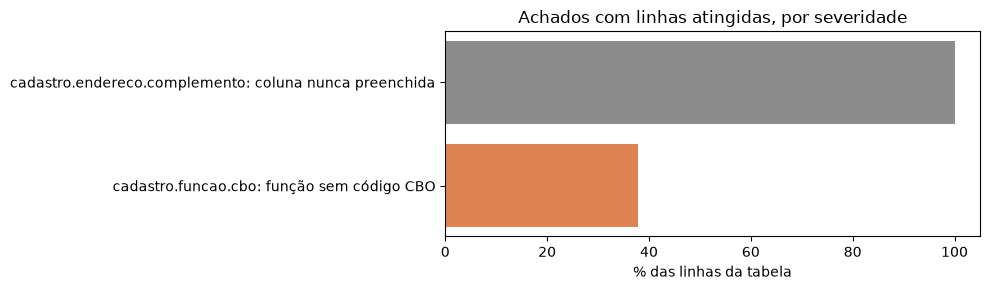

registro gravado em dados/auditoria/cadastro.json


In [24]:
com_linhas = quadro[quadro["linhas"] > 0].sort_values("pct")
if len(com_linhas):
    fig, eixo = plt.subplots(figsize=(10, max(3, 0.4 * len(com_linhas))))
    cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C"}
    eixo.barh(com_linhas["tabela"] + "." + com_linhas["coluna"] + ": " + com_linhas["achado"].str.slice(0, 50), com_linhas["pct"], color=[cores[s] for s in com_linhas["severidade"]])
    eixo.set_xlabel("% das linhas da tabela")
    eixo.set_title("Achados com linhas atingidas, por severidade")
    plt.tight_layout()
    plt.show()
caminho = registro.salvar(REFERENCIA.isoformat())
print(f"registro gravado em {caminho.relative_to(RAIZ)}")
con.close()

## Nota Técnica de fechamento

**O que foi examinado:** as 12 tabelas do domínio `cadastro`, 93 colunas e 17.467 linhas vivas, na carga identificada na seção 2. O exame cobriu tipo, completude, unicidade por chave e por conteúdo, domínios declarados, texto, vigências, integridade referencial e as regras do domínio conferidas contra fontes públicas.

**O veredicto: o cadastro de referência é sólido, e o único defeito grave encontrado era nosso.** Chaves, domínios, referências, vigências e geografia estão íntegros; o texto não tem vício; os nulos são coerentes com a regra que os explica. Os achados que ficam para o catálogo são dois, ambos de ausência: o CBO faltando em 17 das 45 funções (média) e o complemento de endereço nunca preenchido (baixa). O achado de tipo (`TINYINT` copiado como `BOOLEAN`) foi corrigido na ingestão durante esta auditoria e fica registrado para o catálogo saber que a bronze foi recopiada.

**Próximos passos:** carregar os demais anos da fonte de feriados e repetir a conferência; seguir para o domínio comercial, que já usa este cadastro como referência.